In [212]:
# Cell 0: Config (replace ALPHA=0.80 with nothing — computed per country below)
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats
import numpy as np

PATHS = {
    'M0': '../output/results/M0_results_5YCDS.csv',
    'M1': '../output/results/M1_results_5YCDS.csv',
    'M2': '../output/results/M2_results_5YCDS.csv',
}
DATE_COL    = 'date'
COUNTRY_COL = 'country'
DD_COL      = 'distance_to_distress'
CDS_COL     = 'cds_spread'
HORIZONS    = [1, 2, 4, 8]
EXPORTERS   = ['Saudi Arabia', 'Abu Dhabi', 'Qatar', 'Colombia',
               'Mexico', 'Brazil', 'Egypt', 'Malaysia']
CONTROLS    = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
               'South Korea', 'Thailand', 'Turkey']
RECOVERY = 0.40
HORIZON  = 5

In [215]:
# Cell 1: Build df with observed CDS and model DDs
df_obs = pd.read_csv(PATHS['M0'], parse_dates=[DATE_COL],
                     usecols=[DATE_COL, COUNTRY_COL, CDS_COL])

dd_frames = [df_obs.set_index([DATE_COL, COUNTRY_COL])]

for model_name, path in PATHS.items():
    df = pd.read_csv(path, parse_dates=[DATE_COL],
                     usecols=[DATE_COL, COUNTRY_COL, DD_COL])
    df = df.rename(columns={DD_COL: f'DD_{model_name}'})
    dd_frames.append(df.set_index([DATE_COL, COUNTRY_COL]))

panel = pd.concat(dd_frames, axis=1).reset_index()
panel = panel[panel[COUNTRY_COL].isin(EXPORTERS + CONTROLS)].dropna()
panel['group']    = panel[COUNTRY_COL].apply(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
panel['exporter'] = (panel['group'] == 'Exporter').astype(float)

panel

,date,country,cds_spread,DD_M0,DD_M1,DD_M2,group,exporter
0,2015-01-04,Abu Dhabi,69.65999,20.746751,8.133679,4.870465,Exporter,1.0
1,2015-01-11,Abu Dhabi,71.70000,20.750363,6.320827,5.314872,Exporter,1.0
2,2015-01-18,Abu Dhabi,68.68999,20.746132,6.286960,4.690816,Exporter,1.0
3,2015-01-25,Abu Dhabi,68.67999,20.745758,6.264976,4.600571,Exporter,1.0
4,2015-02-01,Abu Dhabi,68.70000,20.738952,5.541897,4.529217,Exporter,1.0
...,...,...,...,...,...,...,...,...
8869,2024-12-01,Turkey,251.12000,-0.384709,-0.375574,-0.384660,Control,0.0
8870,2024-12-08,Turkey,241.90000,-0.360856,-0.351577,-0.360820,Control,0.0
8871,2024-12-15,Turkey,247.11000,-0.364650,-0.357429,-0.364604,Control,0.0
8872,2024-12-22,Turkey,256.52000,-0.367613,-0.359102,-0.367581,Control,0.0


In [208]:
# Cell 2: Summary tables
mean_table = cds_df.groupby(COUNTRY_COL)[
    ['CDS_observed', 'CDS_M0', 'CDS_M1', 'CDS_M2']
].mean().round(2)
mean_table['group'] = mean_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("Mean CDS (bps):")
print(mean_table.sort_values(['group', COUNTRY_COL]).to_string())

cv_table = cds_df.groupby(COUNTRY_COL)[
    ['CDS_observed', 'CDS_M0', 'CDS_M1', 'CDS_M2']
].apply(lambda x: x.std() / x.mean()).round(4)
cv_table['group'] = cv_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("\nCoefficient of Variation:")
print(cv_table.sort_values(['group', COUNTRY_COL]).to_string())

Mean CDS (bps):
              CDS_observed  CDS_M0  CDS_M1  CDS_M2     group
country                                                     
Chile                75.23   16.06  119.22   21.75   Control
China                68.75    0.00   23.67    0.00   Control
Indonesia           116.93    0.20   92.26    4.60   Control
Philippines          77.82    0.00   62.07    0.15   Control
South Africa        228.06    2.03   85.20    3.44   Control
South Korea          40.96    0.00   41.86    0.01   Control
Thailand             60.30    0.00   42.79    0.01   Control
Turkey              362.42  196.09  276.47  196.40   Control
Abu Dhabi            57.84    0.00   56.57    0.12  Exporter
Brazil              219.78    0.03   55.84    0.04  Exporter
Colombia            169.70    2.92  109.44    4.79  Exporter
Egypt               554.35   64.44  128.34   64.53  Exporter
Malaysia             83.95    0.00   60.15    0.30  Exporter
Mexico              124.99    0.48   84.04    2.43  Exporter
Qatar   

In [209]:
# Cell 3: Plot observed vs model-implied CDS
def plot_cds_comparison(country, figsize=(14, 5)):
    fig, ax = plt.subplots(figsize=figsize)

    cdf = cds_df[cds_df[COUNTRY_COL] == country].sort_values(DATE_COL)

    ax.plot(cdf[DATE_COL], cdf['CDS_observed'],
            color='black', linewidth=1.8, label='Observed CDS')

    for model_name in ['M0', 'M1', 'M2']:
        ax.plot(cdf[DATE_COL], cdf[f'CDS_{model_name}'],
                linestyle={'M0': '--', 'M1': '-.', 'M2': '-'}[model_name],
                color={'M0': '#888888', 'M1': '#2166ac', 'M2': '#d6604d'}[model_name],
                linewidth=1.0, label=f'{model_name} implied')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('CDS Spread (bps)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

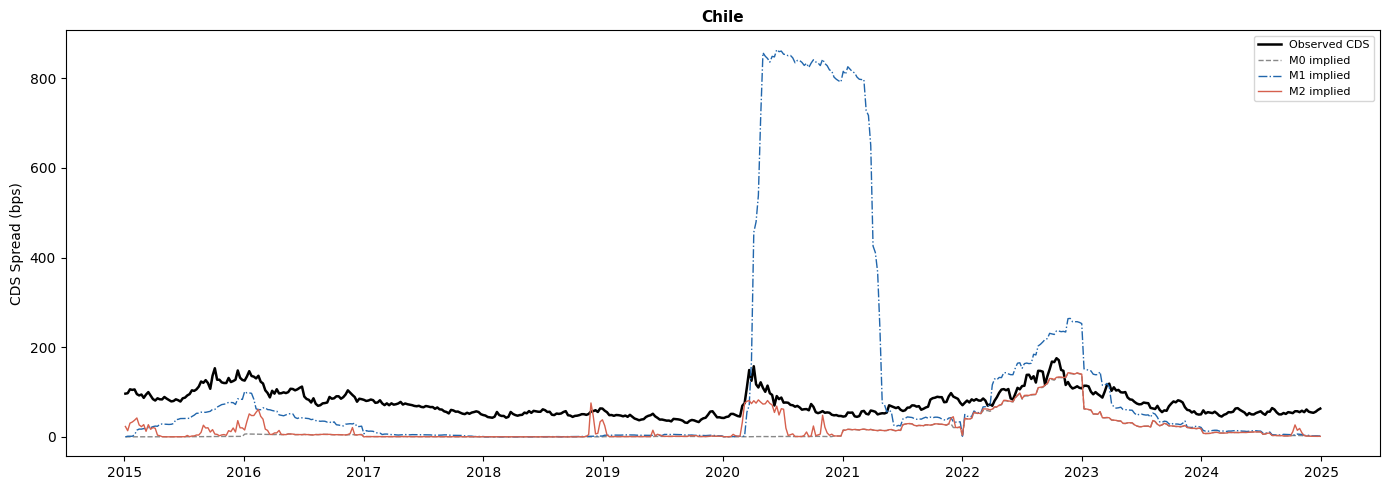

In [211]:
plot_cds_comparison('Chile')

In [196]:
cds_df.to_csv('../output/results/cds_comparison.csv', index=False)

In [107]:
ALPHA_CALIBRATION = {}

df_m0 = pd.read_csv(PATHS['M0'], parse_dates=[DATE_COL],
                    usecols=[DATE_COL, COUNTRY_COL, DD_COL, CDS_COL])

for country in EXPORTERS + CONTROLS:
    cdf = df_m0[df_m0[COUNTRY_COL] == country].dropna(subset=[DD_COL, CDS_COL])

    mean_dd = cdf[DD_COL].mean()
    mean_pd = (1 - np.exp(-(cdf[CDS_COL] / 10000) / (1 - RECOVERY) * HORIZON)).mean()
    mean_pd = np.clip(mean_pd, 1e-6, 1 - 1e-6)

    ALPHA_CALIBRATION[country] = -norm.ppf(mean_pd) / mean_dd

print({k: round(v, 4) for k, v in ALPHA_CALIBRATION.items()})

{'Saudi Arabia': np.float64(0.2001), 'Abu Dhabi': np.float64(0.1341), 'Qatar': np.float64(0.1825), 'Colombia': np.float64(0.2385), 'Mexico': np.float64(0.2196), 'Brazil': np.float64(0.1294), 'Egypt': np.float64(0.0447), 'Malaysia': np.float64(0.16), 'Chile': np.float64(0.4185), 'China': np.float64(0.1415), 'Indonesia': np.float64(0.1831), 'Philippines': np.float64(0.1328), 'South Africa': np.float64(0.1981), 'South Korea': np.float64(0.169), 'Thailand': np.float64(0.1206), 'Turkey': np.float64(0.1617)}
